### NLP with DL Final Project: Context-Aware Sarcasm Detection via Hierarchical Transformer Encoding and Attention-Based Context Modeling
Authors: Artur Sopov & Manjiri Khodke

Abstract: Sarcasm detection remains a challenging problem in Natural Language Processing due to its strong dependence on contextual understanding. Isolated utterances often lack sufficient information to accurately determine sarcasm, making effective context modeling essential. This project proposes a context-aware framework that preserves the full conversational structure using a hierarchical architecture. Each utterance is encoded using a transformer-based model, followed by a context encoder that captures inter-sentence relationships within the conversation. An attention mechanism is then applied to dynamically identify the most relevant contextual cues for sarcasm detection. The resulting context representation is combined with the target utterance and passed to a classifier for final prediction. This approach avoids information loss introduced by summarization methods and enables more precise modeling of contextual dependencies. The model will be evaluated using standard metrics including F1-score, accuracy, and Jaccard coefficient, with the goal of improving robustness in sarcasm detection tasks.

1. Prepare the data.

In [ ]:
import os
from google.colab import drive
drive.mount('/content/gdrive',force_remount=True)
try:
  os.chdir('/content/gdrive/My Drive/Colab Notebooks/nlp_data_utils')
  print('Current working directory changed.')
except FileNotFoundError:
  print("The directory is not found.")

Mounted at /content/gdrive
Current working directory changed.


In [ ]:
import json

with open('./data/sarcasm_data.json', 'r') as file:
    data = json.load(file)

2. Create a 80/10/10 train/validation/test split.

In [ ]:
from sklearn.model_selection import train_test_split

samples = list(data.values())
labels = [1 if sample['sarcasm'] else 0 for sample in samples]

# 80 train
train_data, temp_data, train_labels, temp_labels = train_test_split(
    samples,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

# 10 val/test
val_data, test_data, val_labels, test_labels = train_test_split(
    temp_data,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print(f"Train: {len(train_data)}")
print(f"Val:   {len(val_data)}")
print(f"Test:  {len(test_data)}")

train_data[0]

Train: 552
Val:   69
Test:  69


{'utterance': "But if she dumps you, she'll have a new boyfriend by tomorrow morning and you'll have a new girlfriend when you figure out how to build one.",
 'speaker': 'HOWARD',
 'context': ['Let me ask you something.',
  "Do you think it's okay for Penny to have an ex-boyfriend sleep on her couch?",
  "No, I mean, she's obviously way out of line.",
  'Thank you!'],
 'context_speakers': ['LEONARD', 'LEONARD', 'HOWARD', 'LEONARD'],
 'show': 'BBT',
 'sarcasm': True}

### 3. Prepare the dataset

For each sample $j$, we structure our data into a set of context utterances, a target utterance, and a corresponding label. A crucial aspect is the preservation of speaker information, which is integrated into the input format to allow the DistilBERT encoder ($Enc$) to leverage this information during encoding. Both the context and target utterances are encoded separately.

*   **Context Utterances ($S_{c_j}$)**: This represents the sequence of preceding conversational turns. It is a 2D tensor of shape $N \times L$, where:
    *   $N$ is the number of context utterances in the conversation.
    *   $L$ is the maximum sequence length after tokenization (e.g., 128 tokens).
    Each context utterance includes speaker information prepended to the text, e.g., `[speaker_name]: utterance_text`.

*   **Target Utterance ($S_{t_j}$)**: This is the specific utterance for which sarcasm detection is performed. It is a 1D tensor of shape $L$, representing a single tokenized sequence of length $L$. Similar to context utterances, it also incorporates speaker information.

The encoding process is as follows:

$$U_{c_j} = Enc(S_{c_j})$$
$$U_{t_j} = Enc(S_{t_j})$$

Where:
*   $Enc$ refers to the **DistilBERT tokenizer and model**, which converts the input sequences into numerical embeddings.
*   $U_{c_j}$ and $U_{t_j}$ are the encoded representations of the context and target utterances, respectively.

In [ ]:
import torch

class SarcasmDataset(torch.utils.data.Dataset):
  def __init__(self, split, tokenizer, max_length=128):
    self.tokenizer = tokenizer
    self.max_length = max_length
    self.samples = split
    self.contexts = []
    self.targets = []
    self.labels = []

    for s in self.samples:
      # Preserve the speaker info
      formatted_contexts = [f"[{spk.lower()}]: {txt.lower()}" for spk, txt in zip(s["context_speakers"], s["context"])]
      formatted_target = f"[{s['speaker'].lower()}]: {s['utterance'].lower()}"

      # Tokenize context sentences and target separately per sample
      context_tok = self.tokenizer(
            formatted_contexts,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

      target_tok = self.tokenizer(
            formatted_target,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

      self.contexts.append(context_tok)
      self.targets.append(target_tok)
      self.labels.append(1 if s['sarcasm'] else 0)

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    context = self.contexts[idx]
    target = self.targets[idx]
    label = self.labels[idx]

    return {
        "context_input_ids": context["input_ids"],
        "context_attention_mask": context["attention_mask"],
        "target_input_ids": target["input_ids"].squeeze(0),
        "target_attention_mask": target["attention_mask"].squeeze(0),
        "label": torch.tensor(label, dtype=torch.long)
        }

### 4. Create Hierarchical Model

The model follows a hierarchical architecture designed to capture both local semantic features and global conversational context. The architecture consists of three main components:

1.  **Base Utterance Encoder (DistilBERT)**:
  Each individual utterance (context turns and target) is passed through a shared DistilBERT model to extract high-dimensional semantic embeddings. To optimize for smaller datasets and reduce computational overhead, the weights of this base encoder are frozen ($\text{requires_grad} = \text{False}$).

2. **Mean Pooling**:
  To convert the token-level hidden states into a fixed-length sentence representation, we apply mask-aware mean pooling. This averages the hidden states of only the non-padding tokens for the batch:

  $$h_i = \frac{\sum_{j=1}^{L} (hidden_{i,j} \cdot mask_{i,j})}{\sum_{j=1}^{L} mask_{i,j}}$$

3.  **Contextual Transformer Encoder**:
  The sequence of context embeddings $\mathbf{H}_{\text{context}} = [h_1, h_2, \dots, h_n]$ is fed into a multi-layer Transformer Encoder. This component models the temporal dependencies and conversational flow between different speakers and turns.

  $$\mathbf{H}'_{\text{context}} = \text{TransformerEncoder}(\mathbf{H}_{\text{context}})$$

4.  **Cross-Attention & Fusion**:
  A Cross-Attention mechanism is used to dynamically weigh the importance of different context turns relative to the target utterance. The target embedding acts as the **Query**, while the contextualized context embeddings act as **Keys** and **Values**.

  $$\text{Context}_{\text{vec}} = \text{Attention}(Q = h_{\text{target}}, K = \mathbf{H}'_{\text{context}}, V = \mathbf{H}'_{\text{context}})$$

Finally, the target representation and the attended context vector are concatenated and passed through a non-linear MLP classifier to produce the sarcasm probability.

In [ ]:
from transformers import DistilBertModel, DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

In [ ]:
import torch.nn as nn
import torch

class HierarchicalSarcModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.distil_berta = DistilBertModel.from_pretrained("distilbert-base-uncased")
        # Freeze the weights for DistilBERT
        # No need to compute gradients for the tiny dataset
        for param in self.distil_berta.parameters():
            param.requires_grad = False

        self.hidden_dim = self.distil_berta.config.hidden_size

        # Conversation-level encoder
        self.context_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=self.hidden_dim,
                nhead=4,
                dim_feedforward=self.hidden_dim * 4,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=2
        )

        # Cross-Attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=self.hidden_dim,
            num_heads=4,
            batch_first=True
            )

        self.classifier = nn.Sequential(
            nn.Linear(2*self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(self.hidden_dim, num_classes)
            )

    def mean_pool(self, hidden, mask):
      mask = mask.unsqueeze(-1)
      return (hidden * mask).sum(1)/mask.sum(1).clamp(min=1)

    def forward(self, batch):
        # Target encoding
        target_out = self.distil_berta(input_ids=batch["target_input_ids"], attention_mask=batch["target_attention_mask"])
        target_embed = self.mean_pool(target_out.last_hidden_state, batch["target_attention_mask"])

        # Context encoding
        B,N,L = batch["context_input_ids"].shape
        ctx_ids = batch["context_input_ids"].view(B*N,L)
        ctx_mask = batch["context_attention_mask"].view(B*N,L)
        ctx_out = self.distil_berta(input_ids=ctx_ids, attention_mask=ctx_mask)
        ctx_embed = self.mean_pool(ctx_out. , ctx_mask)
        ctx_embed = ctx_embed.view(B,N,self.hidden_dim)

        # Context Transformer
        src_key_padding_mask = (batch["context_sentence_mask"] == 0)

        # Context Transformer
        ctx_encoded = self.context_encoder(ctx_embed, src_key_padding_mask=src_key_padding_mask)

        # Cross-Attention
        query = target_embed.unsqueeze(1)
        key = ctx_encoded
        value = ctx_encoded
        attn_output, attn_weights = self.cross_attn(
            query=query,
            key=key,
            value=value,
            key_padding_mask=src_key_padding_mask
        )
        context_vector = attn_output.squeeze(1)

        # Fusion
        combined = torch.cat([target_embed, context_vector], dim=-1)
        logits = self.classifier(combined)
        return logits

model = HierarchicalSarcModel()

### 5. Create Collate Function

Because conversations in our dataset have varying numbers of context turns, we implement a custom **Collate Function** to handle batching. Standard data loaders expect fixed-size tensors; our function ensures that all samples in a batch are aligned through dynamic padding.

Key operations performed in the collate function:

*   **Dynamic Padding**: For each batch, we identify the maximum number of context turns ($N_{max}$) and pad shorter conversations with zero-tensors to match this length. This results in a uniform batch shape of $(B, N_{max}, L)$.
*   **Sentence-Level Masking**: We generate a binary `context_sentence_mask` of shape $(B, N_{max})$. This mask informs the Contextual Transformer which indices correspond to actual utterances ($1$ or `True`) and which are padding ($0$ or `False`), preventing the model from attending to empty turns.
*   **Tensor Stacking**: All individual components (context, target, masks, and labels) are stacked into PyTorch tensors for efficient GPU processing.

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def sarcasm_collate(batch):

    max_ctx = max(sample["context_input_ids"].shape[0] for sample in batch)
    context_input_ids = []
    context_attention_mask = []
    context_sentence_mask = []

    for sample in batch:

        n_ctx = sample["context_input_ids"].shape[0]
        pad_ctx = max_ctx - n_ctx
        seq_len = sample["context_input_ids"].shape[1]

        context_input_ids.append(
            torch.cat([sample["context_input_ids"], torch.zeros(pad_ctx, seq_len, dtype=torch.long)], dim=0)
            )

        context_attention_mask.append(
            torch.cat([sample["context_attention_mask"], torch.zeros(pad_ctx, seq_len, dtype=torch.long)], dim=0)
            )

        context_sentence_mask.append(
            torch.cat([torch.ones(n_ctx, dtype=torch.bool), torch.zeros(pad_ctx, dtype=torch.bool)])
            )

    return {
        "context_input_ids": torch.stack(context_input_ids),
        "context_attention_mask": torch.stack(context_attention_mask),
        "context_sentence_mask": torch.stack(context_sentence_mask),
        "target_input_ids": torch.stack([x["target_input_ids"] for x in batch]),
        "target_attention_mask": torch.stack([x["target_attention_mask"]for x in batch]),
        "label": torch.stack([x["label"]for x in batch])
    }

### 6. Training and Optimization

The training process is designed to optimize the model's weights while preventing overfitting on our specific conversational dataset. The pipeline includes the following key components:

*   **Loss Function**: We use **Cross-Entropy Loss** with a **label smoothing** factor of $0.1$. Label smoothing encourages the model to be less overconfident in its predictions, which improves generalization and robustness to noise.
*   **Optimizer**: The **AdamW** optimizer is employed with a learning rate of $3e-4$. We include a weight decay of $0.1$ to provide $L_2$ regularization on the classification head and Transformer layers.
*   **Learning Rate Scheduler**: A **Linear Warmup Scheduler** is used to gradually increase the learning rate at the start of training, followed by a linear decay. This stabilizes the training of the Transformer components.
*   **Evaluation & Checkpointing**: At the end of every epoch, the model is evaluated on the validation set. If the validation loss improves, we save the model state as `nlp_project_best_model.pt`. This ensures that the final model used for testing is the one that performed best on unseen validation data, rather than just the state at the final epoch.

In [ ]:
from transformers import get_scheduler

train_ds = SarcasmDataset(train_data, tokenizer)
val_ds = SarcasmDataset(val_data, tokenizer)
test_ds = SarcasmDataset(test_data, tokenizer)

batch_size = 4

train = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=sarcasm_collate)
val = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=sarcasm_collate)
test = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=sarcasm_collate)

loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
lr = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
num_epochs = 15
num_training_steps = num_epochs * len(train)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

In [ ]:
from tqdm.auto import tqdm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).float()

best_val_loss = float("inf")
train_losses = []
val_losses = []

for epoch in range(num_epochs):
  print(f"\nEpoch {epoch+1}")

  model.train()
  train_loss = 0
  train_correct = 0
  train_total = 0

  for batch in tqdm(train):
    optimizer.zero_grad()

    batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
    labels = batch["label"]

    logits = model(batch)
    loss = loss_fn(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()
    lr_scheduler.step()

    train_loss += loss.item()
    preds = logits.argmax(dim=1)
    train_correct += (preds == labels).sum().item()
    train_total += labels.size(0)

  train_loss /= len(train)
  train_acc = (train_correct / train_total)

  model.eval()
  val_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
      for batch in tqdm(val):
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        labels = batch["label"]

        logits = model(batch)
        loss = loss_fn(logits, labels)
        val_loss += loss.item()
        preds = logits.argmax(dim=1)
        val_correct += (preds == labels).sum().item()
        val_total += labels.size(0)

  val_loss /= len(val)
  val_acc = (val_correct/val_total)

  train_losses.append(train_loss)
  val_losses.append(val_loss)

  print(f"Train Loss: {train_loss:.4f} | " f"Train Acc: {train_acc:.4f}")
  print( f"Val Loss: {val_loss:.4f} | " f"Val Acc: {val_acc:.4f}")

  if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model.state_dict(), "nlp_project_best_model.pt")
      print("Best model saved.")

In [ ]:
Epoch 1
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 38.10it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 49.32it/s]
Train Loss: 0.7337 | Train Acc: 0.5435
Val Loss: 0.7494 | Val Acc: 0.5072
Best model saved.

Epoch 2
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.21it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 50.66it/s]
Train Loss: 0.7078 | Train Acc: 0.5543
Val Loss: 0.8001 | Val Acc: 0.4928

Epoch 3
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 43.65it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 51.24it/s]
Train Loss: 0.6801 | Train Acc: 0.6051
Val Loss: 0.6396 | Val Acc: 0.7101
Best model saved.

Epoch 4
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.80it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 51.31it/s]
Train Loss: 0.6470 | Train Acc: 0.6377
Val Loss: 0.5975 | Val Acc: 0.7246
Best model saved.

Epoch 5
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.75it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 49.51it/s]
Train Loss: 0.7219 | Train Acc: 0.5634
Val Loss: 0.8640 | Val Acc: 0.4928

Epoch 6
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.31it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 49.80it/s]
Train Loss: 0.6708 | Train Acc: 0.6159
Val Loss: 0.6044 | Val Acc: 0.6957

Epoch 7
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.33it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 50.91it/s]
Train Loss: 0.6327 | Train Acc: 0.6793
Val Loss: 0.6416 | Val Acc: 0.5652

Epoch 8
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.21it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 50.14it/s]
Train Loss: 0.5957 | Train Acc: 0.6975
Val Loss: 0.6099 | Val Acc: 0.7681

Epoch 9
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 43.21it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 50.75it/s]
Train Loss: 0.6030 | Train Acc: 0.7156
Val Loss: 0.6241 | Val Acc: 0.6522

Epoch 10
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 41.89it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 49.70it/s]
Train Loss: 0.5781 | Train Acc: 0.7228
Val Loss: 0.6604 | Val Acc: 0.6377

Epoch 11
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.77it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 50.44it/s]
Train Loss: 0.5594 | Train Acc: 0.7536
Val Loss: 0.5882 | Val Acc: 0.7536
Best model saved.

Epoch 12
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.29it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 49.87it/s]
Train Loss: 0.5360 | Train Acc: 0.7572
Val Loss: 0.6942 | Val Acc: 0.6087

Epoch 13
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 41.64it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 49.94it/s]
Train Loss: 0.5492 | Train Acc: 0.7572
Val Loss: 0.6065 | Val Acc: 0.7246

Epoch 14
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 41.83it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 50.33it/s]
Train Loss: 0.5259 | Train Acc: 0.7772
Val Loss: 0.6150 | Val Acc: 0.6957

Epoch 15
100%|█████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.16it/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 49.56it/s]
Train Loss: 0.5247 | Train Acc: 0.7844
Val Loss: 0.6247 | Val Acc: 0.6812

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
epochs_range = list(range(1, num_epochs + 1))
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses, marker='o', label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# plt.show()
plt.savefig("loss.png")

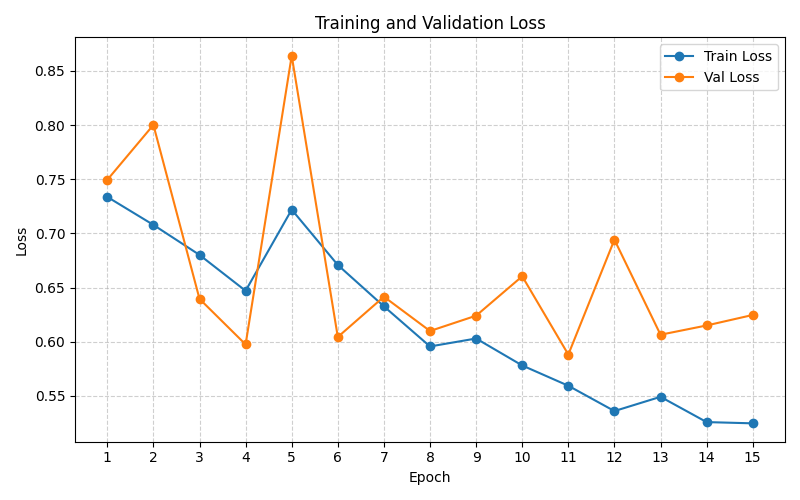

In [ ]:
import os
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    jaccard_score
)

MODEL_PATH = "nlp_project_best_model.pt"

if os.path.exists(MODEL_PATH):
    print(f"Found saved weights at '{MODEL_PATH}'. Loading into model...")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model.to(device)
model.eval()

for split, loader in [('train', train), ('val', val), ('test', test)]:
    print(f"Eval {split}")

    gold = []
    preds = []

    for batch in tqdm(loader, desc=f"Testing {split}"):
        batch = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }

        labels = batch['label'].cpu()
        logits = model(batch)

        pred = torch.argmax(logits, dim=-1).cpu()

        gold.extend(labels.numpy())
        preds.extend(pred.numpy())

    print(f"Accuracy : {accuracy_score(gold, preds):.4f}")
    print(f"Precision: {precision_score(gold, preds, average='binary'):.4f}")
    print(f"Recall   : {recall_score(gold, preds, average='binary'):.4f}")
    print(f"F1 Score : {f1_score(gold, preds, average='binary'):.4f}")
    print(f"Jaccard  : {jaccard_score(gold, preds, average='binary'):.4f}")

In [ ]:
Eval train
Testing train: 100%|██████████████████████████████████████████████████████████████████████████████| 138/138 [00:02<00:00, 46.47it/s]
Accuracy : 0.7572
Precision: 0.7432
Recall   : 0.7862
F1 Score : 0.7641
Jaccard  : 0.6182
Eval val
Testing val: 100%|██████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 49.98it/s]
Accuracy : 0.7536
Precision: 0.7500
Recall   : 0.7714
F1 Score : 0.7606
Jaccard  : 0.6136
Eval test
Testing test: 100%|█████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 50.40it/s]
Accuracy : 0.6522
Precision: 0.6471
Recall   : 0.6471
F1 Score : 0.6471
Jaccard  : 0.4783